# Chapter 122 — Geometric Interpretation of Vectors

> **Prerequisites:** What is a Vector? (ch121), Cartesian coordinates (ch093), distance between points (ch094)
> **You will learn:**
> - How to read a vector geometrically: tail, head, displacement
> - The distinction between free vectors and position vectors
> - How vector equality means same shape, not same location
> - How to visualize vectors in 2D and 3D

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A vector in geometry is a **directed line segment**: it has a starting point (the **tail**) and an ending point (the **head**). The arrow goes from tail to head.

But here is the key geometric fact: **a vector is defined by its displacement, not by its location**. You can slide an arrow anywhere in the plane — as long as you preserve its length and direction, it represents the same vector.

This leads to two ways of anchoring vectors:

- **Position vector:** tail fixed at the origin, head at point P. This uniquely identifies a point in space.
- **Free vector:** tail can be anywhere. Used to represent displacements, forces, and velocities that are not tied to a single point.

**Common misconception:** Drawing a vector from point A to point B does not change the vector — it is still the same object as the same arrow drawn from the origin.

---

## 2. Intuition & Mental Models

**Displacement model:** Think of a vector as a walking instruction: "Go 3 steps east and 2 steps north." It doesn't matter where you start — the instruction is the same. That's a free vector.

**Position model:** Think of a vector as the instruction starting from home base (the origin). This pins the vector to a specific location and identifies a unique point. That's a position vector.

**Computational model:** Think of a vector as the *difference* between two points. Given points A = (1, 2) and B = (4, 5), the vector from A to B is B − A = (3, 3). The same vector (3, 3) drawn from the origin ends at (3, 3).

Recall from ch094 (Distance Between Points) that distance is computed from coordinate differences. Vector subtraction is exactly that: it packages the coordinate differences into a direction.

---

## 3. Visualization

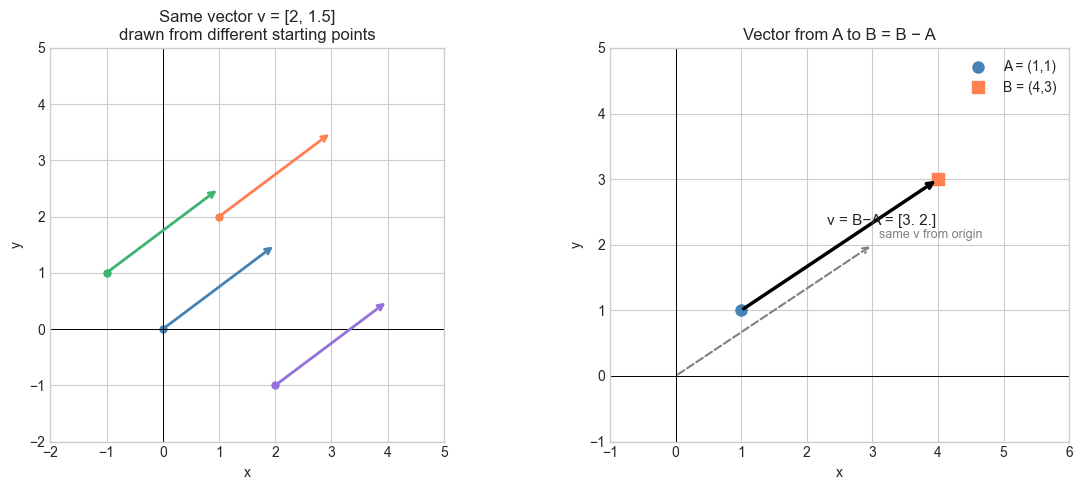

In [1]:
# --- Visualization: Free vectors vs position vectors ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: same vector drawn from different starting points ----
ax = axes[0]
v = np.array([2.0, 1.5])  # the vector
starts = [np.array([0, 0]), np.array([1, 2]), np.array([-1, 1]), np.array([2, -1])]
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for s, c in zip(starts, colors):
    ax.annotate('', xy=s + v, xytext=s,
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax.plot(*s, 'o', color=c, markersize=5)

ax.set_xlim(-2, 5); ax.set_ylim(-2, 5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Same vector v = [2, 1.5]\ndrawn from different starting points')
ax.set_xlabel('x'); ax.set_ylabel('y')

# ---- Right: vector from point A to point B ----
ax = axes[1]
A = np.array([1.0, 1.0])
B = np.array([4.0, 3.0])
v_AB = B - A

ax.plot(*A, 'o', color='steelblue', markersize=8, label='A = (1,1)')
ax.plot(*B, 's', color='coral', markersize=8, label='B = (4,3)')
ax.annotate('', xy=B, xytext=A,
            arrowprops=dict(arrowstyle='->', color='black', lw=2.5))
ax.text(2.3, 2.3, f'v = B−A = {v_AB}', fontsize=11)

# Draw the same vector from the origin
ax.annotate('', xy=v_AB, xytext=[0, 0],
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='dashed'))
ax.text(v_AB[0]+0.1, v_AB[1]+0.1, 'same v from origin', color='gray', fontsize=9)

ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='black', lw=0.7); ax.axvline(0, color='black', lw=0.7)
ax.set_aspect('equal')
ax.set_title('Vector from A to B = B − A')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

Given two points $A = (a_1, a_2)$ and $B = (b_1, b_2)$ in ℝ², the **vector from A to B** is:

$$\overrightarrow{AB} = B - A = \begin{pmatrix} b_1 - a_1 \\ b_2 - a_2 \end{pmatrix}$$

This is the displacement from A to B.

The **position vector** of point P = $(p_1, p_2)$ is:

$$\mathbf{p} = \begin{pmatrix} p_1 \\ p_2 \end{pmatrix}$$

which equals $\overrightarrow{OP}$ where O is the origin.

Vector equality: $\overrightarrow{AB} = \overrightarrow{CD}$ if and only if $B - A = D - C$ component-wise.

In [2]:
# --- Mathematical Formulation: displacement vectors ---
import numpy as np

A = np.array([1.0, 1.0])
B = np.array([4.0, 3.0])
C = np.array([0.0, 2.0])
D = np.array([3.0, 4.0])

v_AB = B - A
v_CD = D - C

print("v_AB = B - A =", v_AB)
print("v_CD = D - C =", v_CD)
print("Are they equal?", np.allclose(v_AB, v_CD))

v_AB = B - A = [3. 2.]
v_CD = D - C = [3. 2.]
Are they equal? True


## 5. Python Implementation

In [3]:
# --- Implementation: displacement_vector and position_vector ---
import numpy as np

def displacement_vector(tail, head):
    """
    Compute the vector from tail to head.

    Args:
        tail: array-like, shape (n,) — starting point
        head: array-like, shape (n,) — ending point

    Returns:
        ndarray, shape (n,) — the displacement vector
    """
    return np.array(head) - np.array(tail)


def vectors_equal(v, w, tol=1e-9):
    """
    Return True if two vectors represent the same displacement.

    Args:
        v, w: array-like, shape (n,)
        tol: numerical tolerance

    Returns:
        bool
    """
    v, w = np.array(v, dtype=float), np.array(w, dtype=float)
    if v.shape != w.shape:
        return False
    return np.max(np.abs(v - w)) < tol


# Test: these two arrows represent the same vector
arrow_1 = displacement_vector([1, 1], [4, 3])
arrow_2 = displacement_vector([0, 2], [3, 4])
arrow_3 = displacement_vector([0, 0], [4, 3])  # different!

print("Arrow 1 (A→B):", arrow_1)
print("Arrow 2 (C→D):", arrow_2)
print("Arrow 3 (O→B):", arrow_3)
print("Arrow 1 == Arrow 2:", vectors_equal(arrow_1, arrow_2))
print("Arrow 1 == Arrow 3:", vectors_equal(arrow_1, arrow_3))

Arrow 1 (A→B): [3 2]
Arrow 2 (C→D): [3 2]
Arrow 3 (O→B): [4 3]
Arrow 1 == Arrow 2: True
Arrow 1 == Arrow 3: False


## 6. Experiments

In [4]:
# --- Experiment 1: Path independence ---
# Hypothesis: the net displacement of a two-leg journey depends only on start and end.
# Try changing: the intermediate point P.
import numpy as np

START = np.array([0.0, 0.0])
END   = np.array([5.0, 3.0])
P     = np.array([2.0, 4.0])  # <-- modify this: try [1,1], [10,-5], [0,0]

leg_1 = P - START
leg_2 = END - P
net   = leg_1 + leg_2
direct = END - START

print("Leg 1 (START→P):", leg_1)
print("Leg 2 (P→END):  ", leg_2)
print("Net displacement:", net)
print("Direct (START→END):", direct)
print("Match?", np.allclose(net, direct))

Leg 1 (START→P): [2. 4.]
Leg 2 (P→END):   [ 3. -1.]
Net displacement: [5. 3.]
Direct (START→END): [5. 3.]
Match? True


In [5]:
# --- Experiment 2: Reversing a vector ---
# Hypothesis: the vector from B to A is the negative of the vector from A to B.
# Try changing: the coordinates of A and B.
import numpy as np

A = np.array([1.0, 2.0])  # <-- modify
B = np.array([4.0, 5.0])  # <-- modify

v_AB = B - A
v_BA = A - B

print("v_AB:", v_AB)
print("v_BA:", v_BA)
print("v_AB + v_BA == zero?", np.allclose(v_AB + v_BA, np.zeros(2)))

v_AB: [3. 3.]
v_BA: [-3. -3.]
v_AB + v_BA == zero? True


## 7. Exercises

**Easy 1.** Given A = (2, −1) and B = (5, 4), compute the vector from A to B. What is the vector from B to A? *(Expected: [3, 5] and [−3, −5])*

**Easy 2.** Draw (using matplotlib) the three points O = (0,0), A = (3, 1), B = (1, 4) and the vectors O→A, O→B, and A→B.

**Medium 1.** A robot starts at (0, 0), moves to (3, 4), then to (1, 7), then to (5, 2). Compute each leg as a displacement vector. Compute the net displacement. Verify it equals the direct vector from start to final position.

**Medium 2.** Given the vector **v** = B − A, find two different pairs of points (A₁, B₁) and (A₂, B₂) such that B₁ − A₁ = B₂ − A₂ = **v**. Show computationally that they represent the same vector.

**Hard.** Prove algebraically (and verify computationally) that for any three points A, B, C: $\overrightarrow{AB} + \overrightarrow{BC} + \overrightarrow{CA} = \mathbf{0}$. What does this mean geometrically? *(Challenge: this is the triangle law — it will reappear in ch125)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: GPS Track Analyzer ---
# Problem: Given a series of GPS coordinates (simplified to 2D),
#          compute the displacement vectors for each step and visualize the path.
# Dataset: generated walking path
# Task: compute per-step vectors, total displacement, and total distance walked

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# GPS waypoints (x, y in meters from starting point)
waypoints = np.array([
    [0,    0],
    [50,   30],
    [80,   80],
    [60,   120],
    [100,  150],
    [140,  130],
    [160,  80],
    [120,  40],
    [90,   10],
], dtype=float)

# TODO 1: Compute displacement vector for each step
# steps = waypoints[1:] - waypoints[:-1]

# TODO 2: Compute the length of each step (Euclidean distance)
# step_lengths = np.linalg.norm(steps, axis=1)

# TODO 3: Total distance walked vs net displacement
# total_distance = ...
# net_displacement = ...

# TODO 4: Visualize the path with arrows for each step
# (use ax.quiver or annotate)

# Starter visualization scaffold:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(waypoints[:, 0], waypoints[:, 1], 'o--', color='gray', alpha=0.5)
ax.plot(*waypoints[0],  's', color='green', markersize=10, label='Start')
ax.plot(*waypoints[-1], '*', color='red',   markersize=12, label='End')
ax.set_title('GPS Walking Path')
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary & Connections

- A vector is defined by its displacement — length and direction — not by its location.
- The vector from A to B is computed as B − A.
- Position vectors anchor at the origin and identify points; free vectors describe displacements.
- Two arrows represent the same vector iff they have identical components.

**Backward connection:** This generalizes point subtraction from ch094 (Distance Between Points). Distance is the length of the displacement vector.

**Forward connections:**
- This will reappear in ch125 — Vector Addition, where the tip-to-tail rule is the geometric version of displacement composition.
- This will reappear in ch129 — Distance in Vector Space, where the magnitude of a displacement vector is exactly the distance between two points.
- This will reappear in ch143 — Vector Transformations, where vectors are mapped to new positions by linear maps.